# TFG — Implementación completa para resultados y conclusiones

Este notebook completa el pipeline experimental del TFG para la clasificación automática de desinformación con WELFake. Añade las celdas necesarias para ejecutar el entrenamiento, guardar métricas, generar matrices de confusión, exportar ejemplos de error y producir gráficos reutilizables en el capítulo de resultados.

In [ ]:
# Instalación de dependencias en Google Colab
!pip -q install datasets transformers evaluate accelerate scikit-learn pyarrow sentencepiece matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


## 1. Importaciones y configuración global

En esta celda se fijan la semilla, los modelos comparados, las carpetas de salida y una opción de ejecución rápida.


In [ ]:
import os
import re
import gc
import time
import math
import random
import hashlib
import inspect
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict, Dataset as HFDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Modelos evaluados en el TFG
BERT_MODEL = "bert-base-uncased"
ROBERTA_MODEL = "roberta-base"

# Carpetas de salida
OUT_DIR = Path("welfake_tfg_prepared")
RESULTS_DIR = Path("welfake_tfg_results")
OUT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Ejecución rápida solo para comprobar que todo funciona. Para resultados finales: False.
USE_DEBUG_SUBSET = False
DEBUG_N = 3000

# Activación de entrenamientos. Para obtener resultados completos, mantener los tres en True.
RUN_BILSTM = True
RUN_BERT = True
RUN_ROBERTA = True

# Hiperparámetros principales
MAX_VOCAB = 50000
MIN_FREQ = 2
LSTM_BATCH_SIZE = 64
LSTM_EPOCHS = 5
LSTM_LR = 1e-3

TRANSFORMER_EPOCHS = 2
TRANSFORMER_LR = 2e-5
TRANSFORMER_BATCH_SIZE = 8

pd.set_option("display.max_colwidth", 160)
LABEL_NAMES = {0: "real", 1: "fake"}

Device: cuda


## 2. Carga del dataset y normalización de columnas

Se carga WELFake desde Hugging Face y se identifican automáticamente las columnas de título, texto y etiqueta.

In [ ]:
ds = load_dataset("davanstrien/WELFake")
data = ds["train"] if isinstance(ds, DatasetDict) and "train" in ds else (list(ds.values())[0] if isinstance(ds, DatasetDict) else ds)

if USE_DEBUG_SUBSET:
    data = data.select(range(min(DEBUG_N, len(data))))
    print(f"Modo debug activo: {len(data):,} ejemplos")

print(data)
print("Columnas:", data.column_names)

cols = {c.lower(): c for c in data.column_names}
title_col = cols.get("title", None)
text_col = cols.get("text", None)
label_col = cols.get("label", None)

if text_col is None or label_col is None:
    raise ValueError(f"No se encuentran columnas esperadas. Columnas disponibles: {data.column_names}")

print("Columna título:", title_col)
print("Columna texto :", text_col)
print("Columna label :", label_col)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-290868f0a36350(…):   0%|          | 0.00/152M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/72134 [00:00<?, ? examples/s]

Dataset({
    features: ['title', 'text', 'label'],
    num_rows: 72134
})
Columnas: ['title', 'text', 'label']
Columna título: title
Columna texto : text
Columna label : label


## 3. Análisis inicial de calidad y limpieza textual

Se revisan valores vacíos, distribución de etiquetas y duplicados. Después se eliminan HTML, URL y espacios redundantes.


In [ ]:
sample_df = data.select(range(min(5000, len(data)))).to_pandas()

def _is_empty(x):
    return (x is None) or (not isinstance(x, str)) or (len(x.strip()) == 0)

empty_text = sample_df[text_col].apply(_is_empty).mean()
empty_title = sample_df[title_col].apply(_is_empty).mean() if title_col else np.nan

print(f"Muestra: {len(sample_df):,} filas")
print(f"% texto vacío/nulo (muestra): {empty_text*100:.2f}%")
if title_col:
    print(f"% título vacío/nulo (muestra): {empty_title*100:.2f}%")

print("\nDistribución de etiquetas original (muestra):")
print(sample_df[label_col].value_counts(normalize=True).rename("proportion"))

dedup_cols = [c for c in [title_col, text_col] if c]
dup_rate = sample_df.duplicated(subset=dedup_cols).mean()
print(f"\n% duplicados exactos (muestra): {dup_rate*100:.2f}%")

URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
HTML_RE = re.compile(r"<.*?>")
WS_RE = re.compile(r"\s+")

def clean_text_basic(text: str) -> str:
    if text is None:
        return ""
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(HTML_RE, " ", text)
    text = re.sub(URL_RE, " ", text)
    text = re.sub(WS_RE, " ", text).strip()
    return text

def build_input_text(title: str, body: str) -> str:
    title = clean_text_basic(title) if title is not None else ""
    body = clean_text_basic(body) if body is not None else ""
    if title:
        return f"{title} [SEP] {body}".strip()
    return body.strip()

def is_valid_raw(example):
    t = example.get(text_col, None)
    return t is not None and isinstance(t, str) and len(t.strip()) > 0

def add_input_text(example):
    title = example.get(title_col, "") if title_col else ""
    body = example.get(text_col, "")
    return {"input_text": build_input_text(title, body)}

def is_valid_after_clean(example):
    txt = example.get("input_text", "")
    return isinstance(txt, str) and len(txt.strip()) > 0

def add_hash(example):
    return {"_hash": hashlib.md5(example["input_text"].encode("utf-8")).hexdigest()}

# Filtrado, limpieza y deduplicación
data_clean = data.filter(is_valid_raw)
data_clean = data_clean.map(add_input_text)
data_clean = data_clean.filter(is_valid_after_clean)

keep_cols = [c for c in [label_col, "input_text"] if c is not None]
drop_cols = [c for c in data_clean.column_names if c not in keep_cols]
data_clean = data_clean.remove_columns(drop_cols)

data_h = data_clean.map(add_hash)
seen = set()
keep_idx = []
for i, h in enumerate(data_h["_hash"]):
    if h not in seen:
        seen.add(h)
        keep_idx.append(i)

data_clean = data_h.select(keep_idx).remove_columns(["_hash"])

print("Tras limpieza y deduplicación:")
print(data_clean)
print("Columnas:", data_clean.column_names)

Muestra: 5,000 filas
% texto vacío/nulo (muestra): 1.22%
% título vacío/nulo (muestra): 0.64%

Distribución de etiquetas original (muestra):
label
1    0.5256
0    0.4744
Name: proportion, dtype: float64

% duplicados exactos (muestra): 0.68%


Filter:   0%|          | 0/72134 [00:00<?, ? examples/s]

Map:   0%|          | 0/71351 [00:00<?, ? examples/s]

Filter:   0%|          | 0/71351 [00:00<?, ? examples/s]

Map:   0%|          | 0/71342 [00:00<?, ? examples/s]

Tras limpieza y deduplicación:
Dataset({
    features: ['label', 'input_text'],
    num_rows: 63100
})
Columnas: ['label', 'input_text']


## 4. Reetiquetado y estadísticas descriptivas

El dataset original se reetiqueta para que la clase positiva sea `fake`. Esta decisión facilita la interpretación directa de `precision`, `recall` y `F1` en relación con la detección de desinformación.

In [ ]:
def remap_target(example):
    original = int(example[label_col])
    # Convención WELFake habitual: 0=fake, 1=real. Nueva convención: 1=fake, 0=real.
    target = 1 if original == 0 else 0
    return {"target": target}

data_clean = data_clean.map(remap_target)

def word_count(s: str) -> int:
    if not isinstance(s, str) or not s:
        return 0
    return len(s.split())

def add_lengths(example):
    txt = example["input_text"]
    return {"n_chars": len(txt), "n_words": word_count(txt)}

data_len = data_clean.map(add_lengths)
n_words = np.array(data_len["n_words"])
n_chars = np.array(data_len["n_chars"])

def describe(arr):
    return {
        "min": int(arr.min()),
        "p50": int(np.quantile(arr, 0.50)),
        "p90": int(np.quantile(arr, 0.90)),
        "p95": int(np.quantile(arr, 0.95)),
        "p99": int(np.quantile(arr, 0.99)),
        "max": int(arr.max()),
        "mean": float(arr.mean())
    }

print("n_words:", describe(n_words))
print("n_chars:", describe(n_chars))

labels = np.array(data_clean["target"])
vals, counts = np.unique(labels, return_counts=True)
print("\nDistribución de clases tras limpieza:")
for v, c in zip(vals, counts):
    print(f"  clase {v} ({LABEL_NAMES[v]}): {c:,} ({c / len(labels) * 100:.2f}%)")

Map:   0%|          | 0/63100 [00:00<?, ? examples/s]

Map:   0%|          | 0/63100 [00:00<?, ? examples/s]

n_words: {'min': 1, 'p50': 417, 'p90': 1120, 'p95': 1418, 'p99': 2690, 'max': 24236, 'mean': 559.9645483359747}
n_chars: {'min': 1, 'p50': 2538, 'p90': 6722, 'p95': 8463, 'p99': 15913, 'max': 143041, 'mean': 3368.3137717908085}

Distribución de clases tras limpieza:
  clase 0 (real): 28,312 (44.87%)
  clase 1 (fake): 34,788 (55.13%)


## 5. Partición estratificada train / valid / test

Se utiliza una división 80/10/10 con estratificación para conservar la proporción de clases en los tres subconjuntos.

In [ ]:
df = data_clean.to_pandas()[["input_text", "target"]].copy()

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["target"]
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["target"]
)

# Reset de índices para evitar problemas al exportar y analizar errores
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

dataset_final = DatasetDict({
    "train": HFDataset.from_pandas(train_df, preserve_index=False),
    "valid": HFDataset.from_pandas(valid_df, preserve_index=False),
    "test": HFDataset.from_pandas(test_df, preserve_index=False),
})

def show_split(name, dframe):
    counts = dframe["target"].value_counts().sort_index()
    print(f"\n{name}: {len(dframe):,} filas")
    for v, c in counts.items():
        print(f"  clase {v} ({LABEL_NAMES[v]}): {c:,} ({c / len(dframe) * 100:.2f}%)")

show_split("train", train_df)
show_split("valid", valid_df)
show_split("test", test_df)

for split, dframe in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    dframe.to_csv(OUT_DIR / f"{split}.csv", index=False)
    dframe.to_parquet(OUT_DIR / f"{split}.parquet", index=False)

dataset_final.save_to_disk(str(OUT_DIR / "hf_dataset"))
print("\nDatos preparados guardados en:", OUT_DIR.resolve())


train: 50,480 filas
  clase 0 (real): 22,650 (44.87%)
  clase 1 (fake): 27,830 (55.13%)

valid: 6,310 filas
  clase 0 (real): 2,831 (44.87%)
  clase 1 (fake): 3,479 (55.13%)

test: 6,310 filas
  clase 0 (real): 2,831 (44.87%)
  clase 1 (fake): 3,479 (55.13%)


Saving the dataset (0/1 shards):   0%|          | 0/50480 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6310 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6310 [00:00<?, ? examples/s]


Datos preparados guardados en: /content/welfake_tfg_prepared


## 6. Longitud de secuencia y tokenización

Se estima una longitud máxima razonable para Transformers a partir de una muestra del conjunto de entrenamiento. Para BiLSTM se usa una longitud basada en palabras.

In [ ]:
def estimate_token_lengths(texts, tokenizer_name, sample_size=2000):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    sample = texts[:min(sample_size, len(texts))]
    lengths = []
    for txt in sample:
        enc = tokenizer(txt, truncation=False, add_special_tokens=True)
        lengths.append(len(enc["input_ids"]))
    return np.array(lengths)

def summarize_lengths(name, arr):
    summary = {
        "p50": int(np.quantile(arr, 0.50)),
        "p90": int(np.quantile(arr, 0.90)),
        "p95": int(np.quantile(arr, 0.95)),
        "p99": int(np.quantile(arr, 0.99)),
        "max_sample": int(arr.max())
    }
    print(name, summary)
    return summary

train_texts = dataset_final["train"]["input_text"]
bert_lengths = estimate_token_lengths(train_texts, BERT_MODEL, sample_size=2000)
roberta_lengths = estimate_token_lengths(train_texts, ROBERTA_MODEL, sample_size=2000)

bert_len_summary = summarize_lengths("BERT", bert_lengths)
roberta_len_summary = summarize_lengths("RoBERTa", roberta_lengths)

MAX_LEN_TRANSFORMER = min(512, int(np.quantile(bert_lengths, 0.95)))
MAX_LEN_LSTM = min(600, int(np.quantile(n_words, 0.95)))

print("MAX_LEN_TRANSFORMER =", MAX_LEN_TRANSFORMER)
print("MAX_LEN_LSTM =", MAX_LEN_LSTM)

pd.DataFrame([
    {"modelo": "BERT", **bert_len_summary},
    {"modelo": "RoBERTa", **roberta_len_summary},
]).to_csv(RESULTS_DIR / "token_length_summary.csv", index=False)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1588 > 512). Running this sequence through the model will result in indexing errors


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1706 > 512). Running this sequence through the model will result in indexing errors


BERT {'p50': 533, 'p90': 1484, 'p95': 1905, 'p99': 3706, 'max_sample': 11510}
RoBERTa {'p50': 536, 'p90': 1508, 'p95': 1957, 'p99': 3838, 'max_sample': 11729}
MAX_LEN_TRANSFORMER = 512
MAX_LEN_LSTM = 600


In [ ]:
def prepare_transformer_dataset(dataset_dict, model_name, max_length):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_batch(batch):
        return tokenizer(
            batch["input_text"],
            truncation=True,
            max_length=max_length
        )

    tokenized = dataset_dict.map(tokenize_batch, batched=True)
    tokenized = tokenized.rename_column("target", "labels")
    keep = ["input_ids", "attention_mask", "labels"]
    if "token_type_ids" in tokenized["train"].column_names:
        keep.append("token_type_ids")
    remove_cols = [c for c in tokenized["train"].column_names if c not in keep]
    tokenized = tokenized.remove_columns(remove_cols)
    return tokenizer, tokenized

bert_tokenizer, bert_ds = prepare_transformer_dataset(dataset_final, BERT_MODEL, MAX_LEN_TRANSFORMER)
roberta_tokenizer, roberta_ds = prepare_transformer_dataset(dataset_final, ROBERTA_MODEL, MAX_LEN_TRANSFORMER)

print(bert_ds)

Map:   0%|          | 0/50480 [00:00<?, ? examples/s]

Map:   0%|          | 0/6310 [00:00<?, ? examples/s]

Map:   0%|          | 0/6310 [00:00<?, ? examples/s]

Map:   0%|          | 0/50480 [00:00<?, ? examples/s]

Map:   0%|          | 0/6310 [00:00<?, ? examples/s]

Map:   0%|          | 0/6310 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50480
    })
    valid: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6310
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6310
    })
})


## 7. Métricas comunes

Todos los modelos se evalúan con las mismas métricas: accuracy, precision, recall, F1, ROC-AUC y matriz de confusión. La clase positiva es fake.

In [ ]:
def binary_metrics_from_probs(labels, probs, threshold=0.5):
    labels = np.asarray(labels).astype(int)
    probs = np.asarray(probs)
    preds = (probs >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except Exception:
        roc_auc = float("nan")
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return binary_metrics_from_probs(labels, probs)

def metrics_for_display(metrics):
    return {k: (round(v, 4) if isinstance(v, float) else v) for k, v in metrics.items()}

## 8. Entrenamiento y evaluación de Transformers

La función siguiente es compatible con distintas versiones de transformers, ya que ajusta automáticamente el nombre del parámetro de evaluación.

In [ ]:
def build_training_args(output_dir, epochs, lr, batch_size):
    base_kwargs = dict(
        output_dir=str(output_dir),
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        seed=SEED,
        report_to="none",
        fp16=torch.cuda.is_available(),
        save_total_limit=1,
    )
    sig = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in sig.parameters:
        base_kwargs["eval_strategy"] = "epoch"
    else:
        base_kwargs["evaluation_strategy"] = "epoch"
    return TrainingArguments(**base_kwargs)

def train_transformer(model_name, tokenized_ds, tokenizer, output_dir, epochs=2, lr=2e-5, batch_size=8):
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    args = build_training_args(output_dir, epochs, lr, batch_size)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["valid"],
        data_collator=collator,
        compute_metrics=compute_metrics_binary,
    )

    t0 = time.perf_counter()
    trainer.train()
    train_time = time.perf_counter() - t0

    val_metrics = trainer.evaluate(tokenized_ds["valid"])
    test_metrics = trainer.evaluate(tokenized_ds["test"])
    return trainer, train_time, val_metrics, test_metrics

def get_transformer_predictions(trainer, tokenized_split, raw_df, model_name):
    pred_out = trainer.predict(tokenized_split)
    probs = torch.softmax(torch.tensor(pred_out.predictions), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    out = raw_df.copy()
    out["modelo"] = model_name
    out["prob_fake"] = probs
    out["pred"] = preds
    out["correcto"] = out["target"].astype(int).values == preds
    out["tipo_error"] = np.where(
        out["correcto"],
        "correcto",
        np.where((out["target"] == 0) & (out["pred"] == 1), "falso_positivo", "falso_negativo")
    )
    return out

## 9. Preparación, entrenamiento y evaluación de BiLSTM

In [ ]:
import re
from torch.utils.data import Dataset
from torch import nn
TOKEN_RE = re.compile(r"\b\w+\b", re.UNICODE)
PAD_ID = 0
UNK_ID = 1

def tokenize_words(text):
    return TOKEN_RE.findall(text.lower())

def build_vocab(texts, max_vocab=50000, min_freq=2):
    counter = Counter()
    for txt in texts:
        counter.update(tokenize_words(txt))
    vocab = {"<PAD>": PAD_ID, "<UNK>": UNK_ID}
    for tok, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_vocab:
            break
        vocab[tok] = len(vocab)
    return vocab

def encode_text_lstm(text, vocab, max_len):
    ids = [vocab.get(tok, UNK_ID) for tok in tokenize_words(text)]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    return ids

class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text_lstm(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        h_fw = h_n[-2]
        h_bw = h_n[-1]
        h = torch.cat([h_fw, h_bw], dim=1)
        h = self.dropout(h)
        return self.fc(h).squeeze(1)

def evaluate_lstm(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(y.numpy().astype(int).tolist())
    return binary_metrics_from_probs(all_labels, all_probs)

def predict_lstm(model, loader, raw_df, model_name="BiLSTM"):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().tolist())
    probs = np.asarray(all_probs)
    preds = (probs >= 0.5).astype(int)
    out = raw_df.copy()
    out["modelo"] = model_name
    out["prob_fake"] = probs
    out["pred"] = preds
    out["correcto"] = out["target"].astype(int).values == preds
    out["tipo_error"] = np.where(
        out["correcto"],
        "correcto",
        np.where((out["target"] == 0) & (out["pred"] == 1), "falso_positivo", "falso_negativo")
    )
    return out

def train_lstm_model(model, train_loader, valid_loader, epochs=5, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state = None
    best_f1 = -1.0
    history = []
    t0 = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        val_metrics = evaluate_lstm(model, valid_loader)
        mean_loss = running_loss / max(len(train_loader), 1)
        history.append({"epoch": epoch, "loss": mean_loss, **val_metrics})
        print(f"Epoch {epoch}/{epochs} | loss={mean_loss:.4f} | val_f1={val_metrics['f1']:.4f} | val_acc={val_metrics['accuracy']:.4f}")

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    train_time = time.perf_counter() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_time, pd.DataFrame(history)

def measure_lstm_inference_time(model, loader, n_samples=512, warmup_batches=3):
    """
    Mide la latencia media de inferencia del LSTM con un warm-up previo
    para evitar que la primera ejecución (más lenta por la inicialización
    de CUDA y la asignación de memoria) sesgue el resultado.
    """
    model.eval()
    # Warm-up: ejecutar varios batches sin contar el tiempo
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= warmup_batches:
                break
            x = x.to(DEVICE)
            _ = model(x)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    seen = 0
    t0 = time.perf_counter()
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            _ = model(x)
            seen += x.size(0)
            if seen >= n_samples:
                break
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    seen = min(seen, n_samples)
    return elapsed / max(seen, 1)

def measure_transformer_inference_time(trainer, dataset_split, n_samples=512, warmup_samples=64):
    """
    Mide la latencia media de inferencia del Transformer con un warm-up previo.
    El primer `predict` siempre carga pesos en GPU y compila kernels, por lo que
    se descarta y la medición real se hace en una segunda pasada.
    """
    warm = dataset_split.select(range(min(warmup_samples, len(dataset_split))))
    _ = trainer.predict(warm)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    subset = dataset_split.select(range(min(n_samples, len(dataset_split))))
    t0 = time.perf_counter()
    _ = trainer.predict(subset)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    return elapsed / len(subset)

## 10. Ejecución completa de experimentos

Esta celda entrena los modelos activados al inicio del notebook, evalúa sobre validación y test, y guarda los resultados en CSV. Si Colab se queda sin memoria, se recomienda ejecutar primero BiLSTM y después los Transformers por separado.

In [ ]:
RUN_BILSTM = True
RUN_BERT = True
RUN_ROBERTA = True

import pandas as pd # Added import for pandas

results = []
prediction_frames = []

# Ensure dataframes are loaded if not already in scope
if 'train_df' not in locals() and 'train_df' not in globals():
    print("Loading dataframes from disk...")
    train_df = pd.read_parquet(OUT_DIR / "train.parquet")
    valid_df = pd.read_parquet(OUT_DIR / "valid.parquet")
    test_df = pd.read_parquet(OUT_DIR / "test.parquet")

def clean_metric_dict(m):
    cleaned = {}
    for k, v in m.items():
        # Trainer suele devolver claves tipo eval_accuracy
        nk = k.replace("eval_", "")
        if isinstance(v, (int, float, np.integer, np.floating)):
            cleaned[nk] = float(v)
    return cleaned

def add_result(model_name, val_metrics, test_metrics, train_time=None, infer_time=None, peak_mem_mb=None):
    val_m = clean_metric_dict(val_metrics)
    test_m = clean_metric_dict(test_metrics)
    row = {
        "modelo": model_name,
        "val_accuracy": val_m.get("accuracy"),
        "val_precision": val_m.get("precision"),
        "val_recall": val_m.get("recall"),
        "val_f1": val_m.get("f1"),
        "val_roc_auc": val_m.get("roc_auc"),
        "test_accuracy": test_m.get("accuracy"),
        "test_precision": test_m.get("precision"),
        "test_recall": test_m.get("recall"),
        "test_f1": test_m.get("f1"),
        "test_roc_auc": test_m.get("roc_auc"),
        "tn": int(test_m.get("tn", 0)),
        "fp": int(test_m.get("fp", 0)),
        "fn": int(test_m.get("fn", 0)),
        "tp": int(test_m.get("tp", 0)),
        "train_time_s": train_time,
        "infer_time_s_per_sample": infer_time,
        "infer_time_ms_per_sample": None if infer_time is None else infer_time * 1000,
        "peak_gpu_mem_mb": peak_mem_mb,
    }
    results.append(row)

# BiLSTM
if RUN_BILSTM:
    print("\n=== Entrenando BiLSTM ===")
    vocab = build_vocab(train_df["input_text"], max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
    print("Tamaño vocabulario:", len(vocab))

    train_lstm_ds = LSTMDataset(train_df["input_text"], train_df["target"], vocab, MAX_LEN_LSTM)
    valid_lstm_ds = LSTMDataset(valid_df["input_text"], valid_df["target"], vocab, MAX_LEN_LSTM)
    test_lstm_ds = LSTMDataset(test_df["input_text"], test_df["target"], vocab, MAX_LEN_LSTM)

    train_loader = DataLoader(train_lstm_ds, batch_size=LSTM_BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_lstm_ds, batch_size=LSTM_BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_lstm_ds, batch_size=LSTM_BATCH_SIZE, shuffle=False)

    bilstm_model = BiLSTMClassifier(vocab_size=len(vocab)).to(DEVICE)
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    bilstm_model, bilstm_train_time, bilstm_history = train_lstm_model(
        bilstm_model, train_loader, valid_loader, epochs=LSTM_EPOCHS, lr=LSTM_LR
    )
    bilstm_peak_mem = (
        torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else None
    )
    bilstm_history.to_csv(RESULTS_DIR / "bilstm_training_history.csv", index=False)

    bilstm_val_metrics = evaluate_lstm(bilstm_model, valid_loader)
    bilstm_test_metrics = evaluate_lstm(bilstm_model, test_loader)
    bilstm_infer_time = measure_lstm_inference_time(bilstm_model, test_loader)
    add_result("BiLSTM", bilstm_val_metrics, bilstm_test_metrics,
               bilstm_train_time, bilstm_infer_time, bilstm_peak_mem)

    bilstm_preds = predict_lstm(bilstm_model, test_loader, test_df, model_name="BiLSTM")
    prediction_frames.append(bilstm_preds)
    torch.save(bilstm_model.state_dict(), RESULTS_DIR / "bilstm_model.pt")
    # Guardar vocabulario para reproducibilidad
    import pickle
    with open(RESULTS_DIR / "bilstm_vocab.pkl", "wb") as fvocab:
        pickle.dump(vocab, fvocab)
    print("BiLSTM test:", metrics_for_display(bilstm_test_metrics))

    del bilstm_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# BERT
if RUN_BERT:
    print("\n=== Entrenando BERT ===")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    bert_trainer, bert_train_time, bert_val_metrics, bert_test_metrics = train_transformer(
        BERT_MODEL, bert_ds, bert_tokenizer, output_dir=RESULTS_DIR / "bert_welfake",
        epochs=TRANSFORMER_EPOCHS, lr=TRANSFORMER_LR, batch_size=TRANSFORMER_BATCH_SIZE
    )
    bert_peak_mem = (
        torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else None
    )
    bert_infer_time = measure_transformer_inference_time(bert_trainer, bert_ds["test"])
    add_result("BERT", bert_val_metrics, bert_test_metrics,
               bert_train_time, bert_infer_time, bert_peak_mem)
    bert_preds = get_transformer_predictions(bert_trainer, bert_ds["test"], test_df, model_name="BERT")
    prediction_frames.append(bert_preds)
    print("BERT test:", metrics_for_display(clean_metric_dict(bert_test_metrics)))

    del bert_trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# RoBERTa
if RUN_ROBERTA:
    print("\n=== Entrenando RoBERTa ===")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    roberta_trainer, roberta_train_time, roberta_val_metrics, roberta_test_metrics = train_transformer(
        ROBERTA_MODEL, roberta_ds, roberta_tokenizer, output_dir=RESULTS_DIR / "roberta_welfake",
        epochs=TRANSFORMER_EPOCHS, lr=TRANSFORMER_LR, batch_size=TRANSFORMER_BATCH_SIZE
    )
    roberta_peak_mem = (
        torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else None
    )
    roberta_infer_time = measure_transformer_inference_time(roberta_trainer, roberta_ds["test"])
    add_result("RoBERTa", roberta_val_metrics, roberta_test_metrics,
               roberta_train_time, roberta_infer_time, roberta_peak_mem)
    roberta_preds = get_transformer_predictions(roberta_trainer, roberta_ds["test"], test_df, model_name="RoBERTa")
    prediction_frames.append(roberta_preds)
    print("RoBERTa test:", metrics_for_display(clean_metric_dict(roberta_test_metrics)))

    del roberta_trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results).sort_values("test_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_DIR / "resultados_modelos.csv", index=False)
print("\nTabla final de resultados:")
display(results_df)

if prediction_frames:
    predictions_df = pd.concat(prediction_frames, ignore_index=True)
    predictions_df.to_csv(RESULTS_DIR / "predicciones_test_por_modelo.csv", index=False)
    errors_df = predictions_df[predictions_df["correcto"] == False].copy()
    errors_df["texto_preview"] = errors_df["input_text"].str.slice(0, 500)
    errors_df[["modelo", "target", "pred", "prob_fake", "tipo_error", "texto_preview"]].to_csv(
        RESULTS_DIR / "ejemplos_errores_test.csv", index=False
    )
    print("\nErrores por modelo:")
    display(errors_df.groupby(["modelo", "tipo_error"]).size().reset_index(name="n"))

print("\nArchivos guardados en:", RESULTS_DIR.resolve())


=== Entrenando BiLSTM ===
Tamaño vocabulario: 50000
Epoch 1/5 | loss=0.2073 | val_f1=0.9564 | val_acc=0.9523
Epoch 2/5 | loss=0.1004 | val_f1=0.9563 | val_acc=0.9532
Epoch 3/5 | loss=0.0644 | val_f1=0.9636 | val_acc=0.9605
Epoch 4/5 | loss=0.0361 | val_f1=0.9660 | val_acc=0.9631
Epoch 5/5 | loss=0.0213 | val_f1=0.9661 | val_acc=0.9634
BiLSTM test: {'accuracy': 0.9621, 'precision': 0.9859, 'recall': 0.9448, 'f1': 0.9649, 'roc_auc': np.float64(0.9922), 'tn': 2784, 'fp': 47, 'fn': 192, 'tp': 3287}

=== Entrenando BERT ===


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Tn,Fp,Fn,Tp
1,0.053294,0.044282,0.990333,0.996514,0.985915,0.991186,0.999797,2819,12,49,3430
2,0.010734,0.032347,0.994136,0.994540,0.994826,0.994683,0.999863,2812,19,18,3461


...

RoBERTa test: {'loss': 0.0121, 'accuracy': 0.9984, 'precision': 0.9977, 'recall': 0.9994, 'f1': 0.9986, 'roc_auc': 1.0, 'tn': 2823.0, 'fp': 8.0, 'fn': 2.0, 'tp': 3477.0, 'runtime': 53.1045, 'samples_per_second': 118.822, 'steps_per_second': 14.858, 'epoch': 2.0}

Tabla final de resultados:


,modelo,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,tn,fp,fn,tp,train_time_s,infer_time_s_per_sample,infer_time_ms_per_sample,peak_gpu_mem_mb
0,RoBERTa,0.997147,0.996557,0.998275,0.997415,0.999966,0.998415,0.997704,0.999425,0.998564,0.999957,2823,8,2,3477,3468.652633,0.008616,8.616036,3298.609863
1,BERT,0.994136,0.994540,0.994826,0.994683,0.999863,0.995563,0.993705,0.998275,0.995985,0.999911,2809,22,6,3473,3354.202227,0.009134,9.133505,3122.830566
2,BiLSTM,0.963391,0.987103,0.945961,0.966094,0.991813,0.962124,0.985903,0.944812,0.964920,0.992166,2784,47,192,3287,220.964630,0.000369,0.369420,1049.333496



Errores por modelo:


,modelo,tipo_error,n
0,BERT,falso_negativo,6
1,BERT,falso_positivo,22
2,BiLSTM,falso_negativo,192
3,BiLSTM,falso_positivo,47
4,RoBERTa,falso_negativo,2
5,RoBERTa,falso_positivo,8



Archivos guardados en: /content/welfake_tfg_results


## 11. Figuras para el capítulo de resultados

Se generan gráficos comparativos de métricas, tiempo de entrenamiento, latencia de inferencia y matrices de confusión. Las figuras se guardan en la carpeta `welfake_tfg_results`.

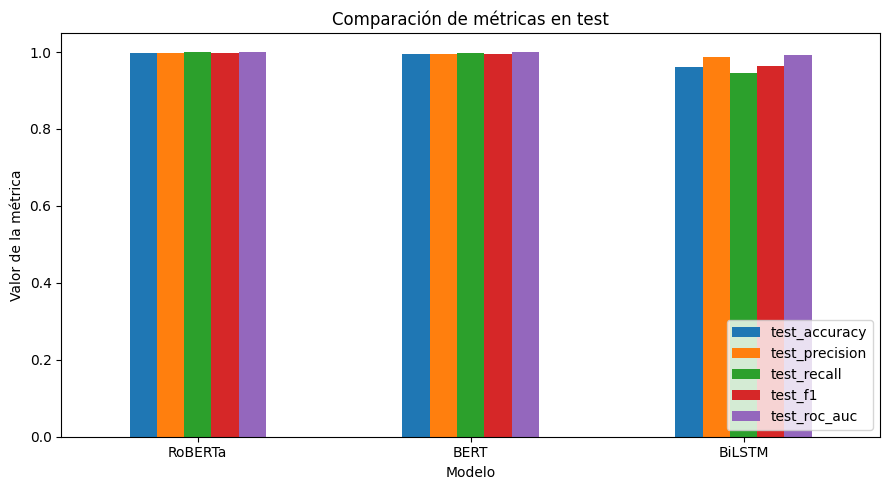

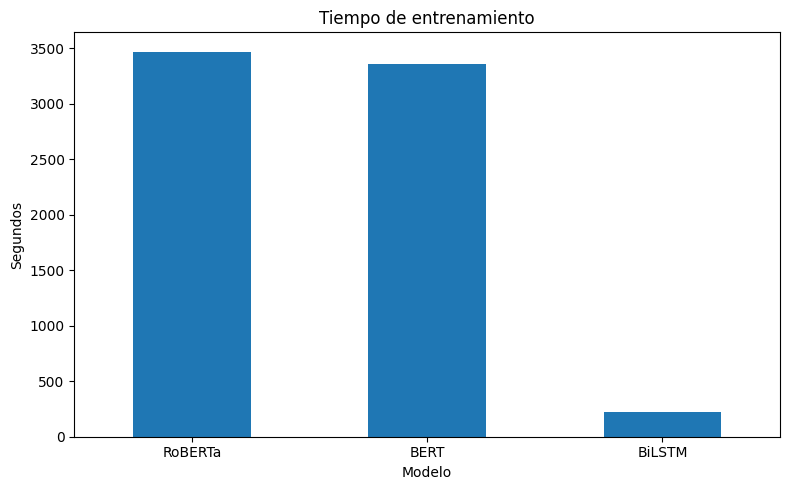

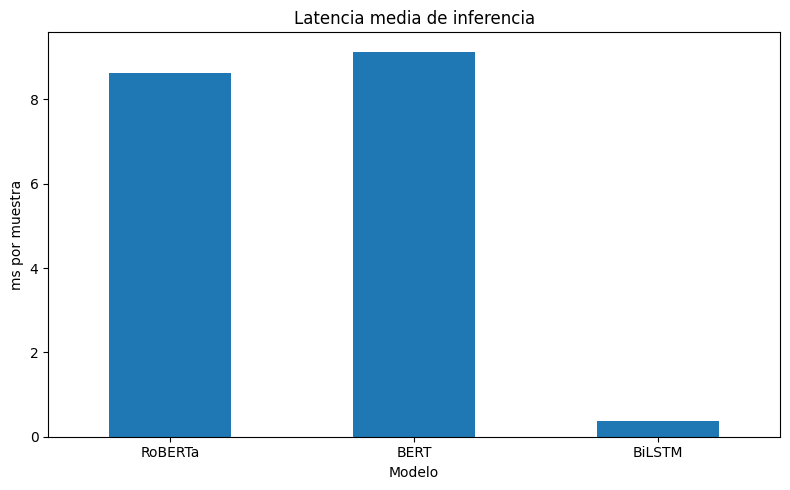

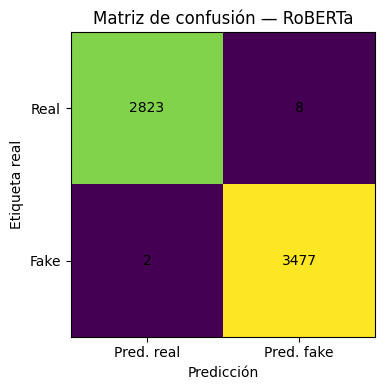

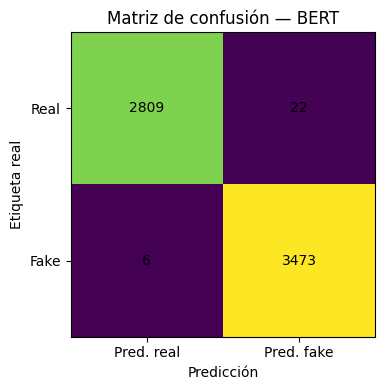

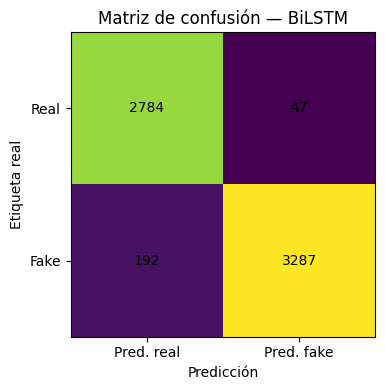

In [ ]:
def save_bar_plot(df, columns, title, ylabel, filename):
    ax = df.set_index("modelo")[columns].plot(kind="bar", figsize=(9, 5))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Modelo")
    ax.set_ylim(0, 1.05 if "métrica" in ylabel.lower() or "valor" in ylabel.lower() else None)
    ax.legend(loc="lower right")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / filename, dpi=200)
    plt.show()

def plot_single_bar(df, column, title, ylabel, filename):
    ax = df.set_index("modelo")[column].plot(kind="bar", figsize=(8, 5))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Modelo")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / filename, dpi=200)
    plt.show()

def plot_confusion_matrix_from_row(row):
    cm = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(f"Matriz de confusión — {row['modelo']}")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred. real", "Pred. fake"])
    ax.set_yticklabels(["Real", "Fake"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")
    plt.tight_layout()
    filename = f"matriz_confusion_{row['modelo'].lower().replace(' ', '_')}.png"
    plt.savefig(RESULTS_DIR / filename, dpi=200)
    plt.show()

if len(results_df) > 0:
    save_bar_plot(
        results_df,
        ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"],
        "Comparación de métricas en test",
        "Valor de la métrica",
        "comparacion_metricas_test.png"
    )
    plot_single_bar(results_df, "train_time_s", "Tiempo de entrenamiento", "Segundos", "tiempo_entrenamiento.png")
    plot_single_bar(results_df, "infer_time_ms_per_sample", "Latencia media de inferencia", "ms por muestra", "latencia_inferencia.png")
    for _, row in results_df.iterrows():
        plot_confusion_matrix_from_row(row)
else:
    print("No hay resultados todavía. Ejecuta primero la celda de entrenamiento completo.")

## 11.5 Análisis por longitud de texto
Esta celda divide el conjunto de prueba en bins de longitud (en palabras del texto unificado) y calcula F1, accuracy y recall por modelo y por bin.El resultado se guarda como CSV y como gráfico.


Métricas por bin de longitud:


/tmp/ipykernel_8738/1737171710.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics_for_group)


,modelo,length_bin,n_examples,n_fake,accuracy,precision,recall,f1
0,BERT,corto (<= 323 palabras),2086.0,1127.0,0.995686,0.992945,0.999113,0.996019
1,BERT,medio (324-550 palabras),2079.0,990.0,0.996633,0.992979,1.000000,0.996477
2,BERT,largo (> 550 palabras),2145.0,1362.0,0.994406,0.994868,0.996329,0.995598
3,BiLSTM,corto (<= 323 palabras),2086.0,1127.0,0.980825,0.992747,0.971606,0.982063
4,BiLSTM,medio (324-550 palabras),2079.0,990.0,0.965368,0.981132,0.945455,0.962963
5,BiLSTM,largo (> 550 palabras),2145.0,1362.0,0.940793,0.983555,0.922173,0.951876
6,RoBERTa,corto (<= 323 palabras),2086.0,1127.0,0.999521,1.000000,0.999113,0.999556
7,RoBERTa,medio (324-550 palabras),2079.0,990.0,0.999519,0.998991,1.000000,0.999495
8,RoBERTa,largo (> 550 palabras),2145.0,1362.0,0.996270,0.994883,0.999266,0.997070


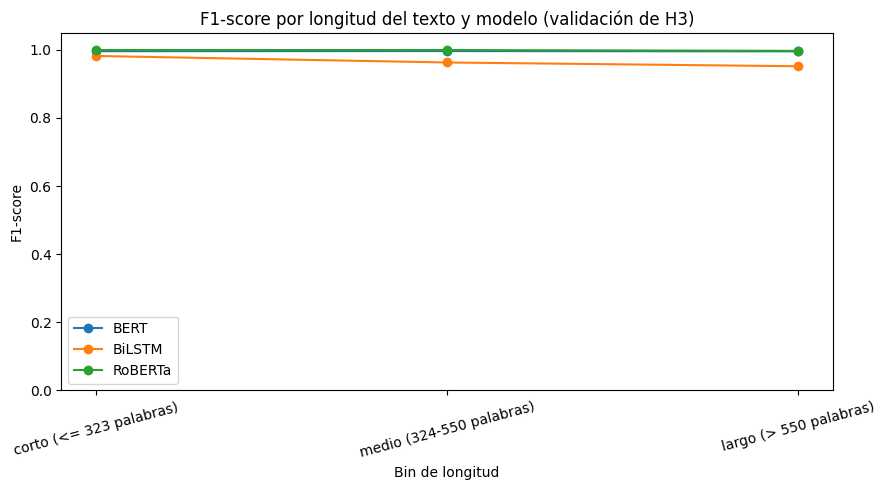

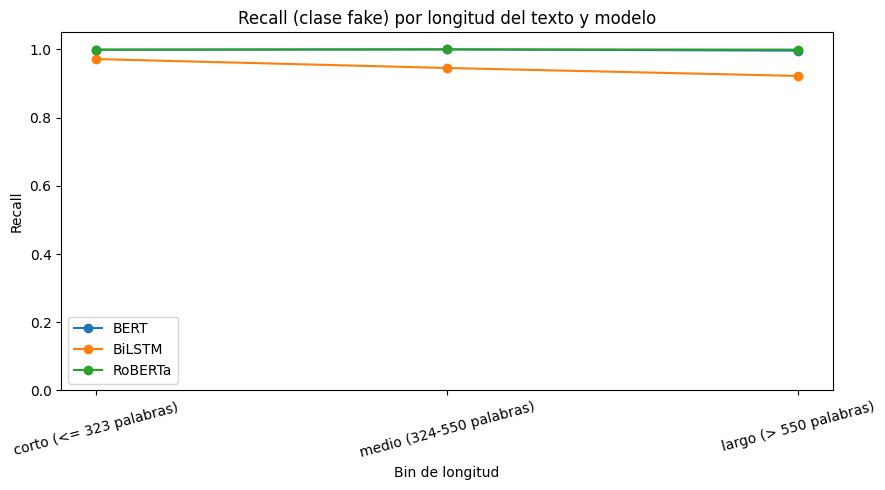


Diferencia de F1 frente a BiLSTM por bin (positivo = Transformer mejor):


modelo,BERT,BiLSTM,RoBERTa,BERT - BiLSTM,RoBERTa - BiLSTM
length_bin,,,,,
corto (<= 323 palabras),0.996019,0.982063,0.999556,0.013957,0.017493
medio (324-550 palabras),0.996477,0.962963,0.999495,0.033514,0.036532
largo (> 550 palabras),0.995598,0.951876,0.997070,0.043722,0.045194


In [ ]:
if "predictions_df" not in globals():
    # Si se ha reiniciado el kernel, recargar predicciones desde disco
    pred_path = RESULTS_DIR / "predicciones_test_por_modelo.csv"
    if pred_path.exists():
        predictions_df = pd.read_csv(pred_path)
    else:
        raise RuntimeError("No hay predicciones cargadas. Ejecuta primero la sección 10.")

# Calcular longitud en palabras del texto unificado
predictions_df = predictions_df.copy()
predictions_df["n_words"] = predictions_df["input_text"].astype(str).str.split().apply(len)

# Definir bins basados en cuantiles del conjunto de test
q33, q66 = predictions_df["n_words"].quantile([0.33, 0.66]).values
def length_bin(n):
    if n <= q33:
        return f"corto (<= {int(q33)} palabras)"
    elif n <= q66:
        return f"medio ({int(q33)+1}-{int(q66)} palabras)"
    else:
        return f"largo (> {int(q66)} palabras)"

predictions_df["length_bin"] = predictions_df["n_words"].apply(length_bin)

# Calcular métricas por (modelo, bin)
def metrics_for_group(g):
    y_true = g["target"].astype(int).values
    y_pred = g["pred"].astype(int).values
    if len(np.unique(y_true)) < 2:
        # Si en el bin solo hay una clase, F1 binario no es informativo; lo marcamos
        precision = recall = f1 = float("nan")
    else:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", pos_label=1, zero_division=0
        )
    return pd.Series({
        "n_examples": len(g),
        "n_fake": int((y_true == 1).sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

length_table = (
    predictions_df.groupby(["modelo", "length_bin"], sort=False)
    .apply(metrics_for_group)
    .reset_index()
)

# Ordenar bins de menor a mayor longitud
bin_order = sorted(predictions_df["length_bin"].unique(), key=lambda x: ("corto" not in x, "medio" not in x, x))
length_table["length_bin"] = pd.Categorical(length_table["length_bin"], categories=bin_order, ordered=True)
length_table = length_table.sort_values(["modelo", "length_bin"]).reset_index(drop=True)

print("Métricas por bin de longitud:")
display(length_table)
length_table.to_csv(RESULTS_DIR / "metricas_por_longitud.csv", index=False)

# Gráfico: F1 por bin de longitud y modelo
fig, ax = plt.subplots(figsize=(9, 5))
for modelo in length_table["modelo"].unique():
    sub = length_table[length_table["modelo"] == modelo]
    ax.plot(sub["length_bin"].astype(str), sub["f1"], marker="o", label=modelo)
ax.set_title("F1-score por longitud del texto y modelo (validación de H3)")
ax.set_ylabel("F1-score")
ax.set_xlabel("Bin de longitud")
ax.set_ylim(0, 1.05)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "f1_por_longitud.png", dpi=200)
plt.show()

# Gráfico: recall por bin de longitud (especialmente relevante para fake news)
fig, ax = plt.subplots(figsize=(9, 5))
for modelo in length_table["modelo"].unique():
    sub = length_table[length_table["modelo"] == modelo]
    ax.plot(sub["length_bin"].astype(str), sub["recall"], marker="o", label=modelo)
ax.set_title("Recall (clase fake) por longitud del texto y modelo")
ax.set_ylabel("Recall")
ax.set_xlabel("Bin de longitud")
ax.set_ylim(0, 1.05)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "recall_por_longitud.png", dpi=200)
plt.show()

# Diferencia (Transformer mejor) - (BiLSTM) por bin: una sola línea por Transformer
print("\nDiferencia de F1 frente a BiLSTM por bin (positivo = Transformer mejor):")
pivot_f1 = length_table.pivot(index="length_bin", columns="modelo", values="f1")
if "BiLSTM" in pivot_f1.columns:
    for col in pivot_f1.columns:
        if col != "BiLSTM":
            pivot_f1[f"{col} - BiLSTM"] = pivot_f1[col] - pivot_f1["BiLSTM"]
display(pivot_f1)
pivot_f1.to_csv(RESULTS_DIR / "diferencia_f1_por_longitud.csv")

## 11.6 Curvas ROC, Precision-Recall y reporte por clase
Esta celda genera:- Curvas ROC para los tres modelos en el conjunto de test, con el AUC ya calculado.- Curvas Precision-Recall, que son más informativas cuando la clase de interés no es ampliamente mayoritaria.

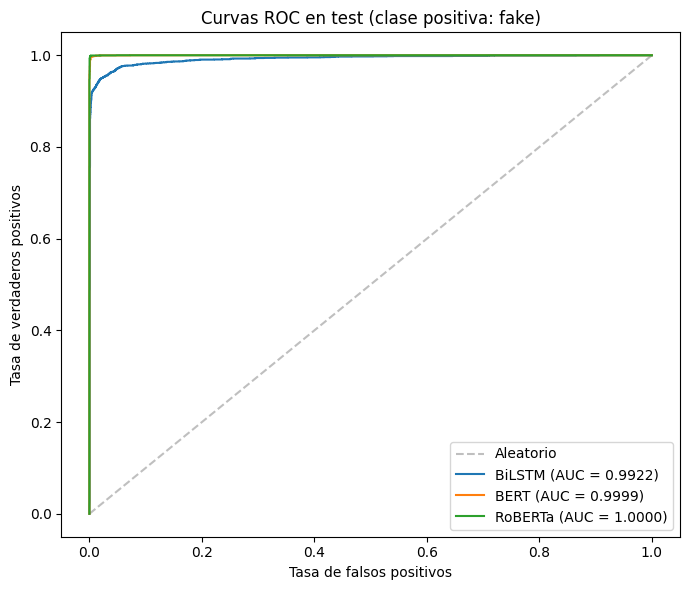

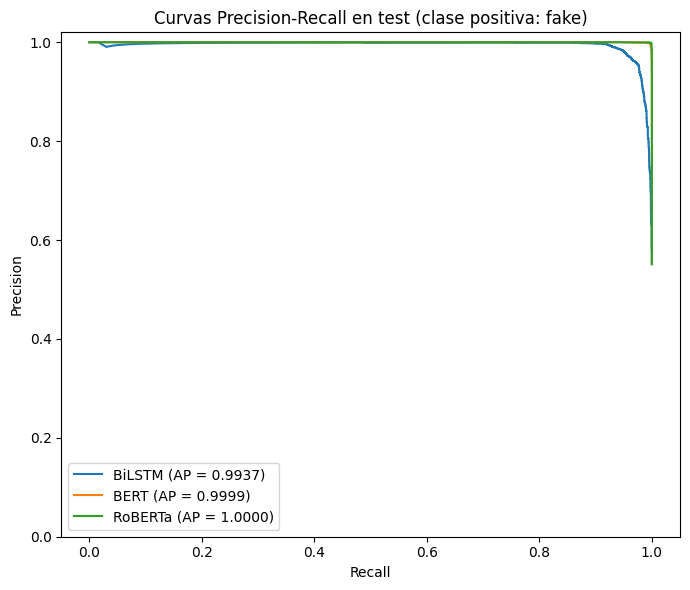


Reporte por clase y modelo:


,modelo,clase,precision,recall,f1-score,support
0,BiLSTM,real,0.935484,0.983398,0.958843,2831.0
1,BiLSTM,fake,0.985903,0.944812,0.964920,3479.0
2,BiLSTM,macro avg,0.960693,0.964105,0.961881,6310.0
3,BiLSTM,weighted avg,0.963282,0.962124,0.962193,6310.0
4,BERT,real,0.997869,0.992229,0.995041,2831.0
5,BERT,fake,0.993705,0.998275,0.995985,3479.0
6,BERT,macro avg,0.995787,0.995252,0.995513,6310.0
7,BERT,weighted avg,0.995573,0.995563,0.995561,6310.0
8,RoBERTa,real,0.999292,0.997174,0.998232,2831.0
9,RoBERTa,fake,0.997704,0.999425,0.998564,3479.0


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, classification_report

if "predictions_df" not in globals():
    pred_path = RESULTS_DIR / "predicciones_test_por_modelo.csv"
    if pred_path.exists():
        predictions_df = pd.read_csv(pred_path)
    else:
        raise RuntimeError("No hay predicciones cargadas. Ejecuta primero la sección 10.")

# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="Aleatorio")
for modelo in predictions_df["modelo"].unique():
    sub = predictions_df[predictions_df["modelo"] == modelo]
    fpr, tpr, _ = roc_curve(sub["target"].astype(int), sub["prob_fake"])
    auc_value = roc_auc_score(sub["target"].astype(int), sub["prob_fake"])
    ax.plot(fpr, tpr, label=f"{modelo} (AUC = {auc_value:.4f})")
ax.set_title("Curvas ROC en test (clase positiva: fake)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "curvas_roc.png", dpi=200)
plt.show()

# Curvas Precision-Recall
fig, ax = plt.subplots(figsize=(7, 6))
for modelo in predictions_df["modelo"].unique():
    sub = predictions_df[predictions_df["modelo"] == modelo]
    precision_curve, recall_curve, _ = precision_recall_curve(sub["target"].astype(int), sub["prob_fake"])
    ap = average_precision_score(sub["target"].astype(int), sub["prob_fake"])
    ax.plot(recall_curve, precision_curve, label=f"{modelo} (AP = {ap:.4f})")
ax.set_title("Curvas Precision-Recall en test (clase positiva: fake)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "curvas_pr.png", dpi=200)
plt.show()

# Reporte por clase para cada modelo
class_reports = []
for modelo in predictions_df["modelo"].unique():
    sub = predictions_df[predictions_df["modelo"] == modelo]
    report = classification_report(
        sub["target"].astype(int), sub["pred"].astype(int),
        labels=[0, 1],
        target_names=["real", "fake"],
        output_dict=True,
        zero_division=0,
    )
    for cls_name, cls_metrics in report.items():
        if isinstance(cls_metrics, dict):
            class_reports.append({
                "modelo": modelo,
                "clase": cls_name,
                "precision": cls_metrics.get("precision"),
                "recall": cls_metrics.get("recall"),
                "f1-score": cls_metrics.get("f1-score"),
                "support": cls_metrics.get("support"),
            })

class_report_df = pd.DataFrame(class_reports)
print("\nReporte por clase y modelo:")
display(class_report_df)
class_report_df.to_csv(RESULTS_DIR / "reporte_por_clase.csv", index=False)

## 11.7 Tablas listas para la memoria
Esta celda genera una tabla en formato Markdown con los resultados principales.


In [ ]:
def format_pct(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/D"
    return f"{x*100:.2f}%"

def format_seconds(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/D"
    return f"{x:.2f} s"

def format_ms(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/D"
    return f"{x:.3f} ms"

def format_mb(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/D"
    return f"{x:.1f} MB"

# Tabla de resultados principales (Markdown)
md_lines = []
md_lines.append("| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC | T. entrenamiento | Latencia | Pico GPU |")
md_lines.append("| --- | --- | --- | --- | --- | --- | --- | --- | --- |")
for _, row in results_df.iterrows():
    md_lines.append("| {modelo} | {acc} | {pre} | {rec} | {f1} | {auc} | {tt} | {lat} | {mem} |".format(
        modelo=row["modelo"],
        acc=format_pct(row["test_accuracy"]),
        pre=format_pct(row["test_precision"]),
        rec=format_pct(row["test_recall"]),
        f1=format_pct(row["test_f1"]),
        auc=format_pct(row["test_roc_auc"]),
        tt=format_seconds(row["train_time_s"]),
        lat=format_ms(row["infer_time_ms_per_sample"]),
        mem=format_mb(row.get("peak_gpu_mem_mb")),
    ))

md_table = "\n".join(md_lines)
print("Tabla en Markdown (lista para pegar en la memoria):\n")
print(md_table)
with open(RESULTS_DIR / "tabla_resultados.md", "w", encoding="utf-8") as f:
    f.write(md_table)

# Tabla en LaTeX (formato sencillo, columnas escalables)
latex_lines = [
    "\\begin{table}[h]",
    "\\centering",
    "\\caption{Resultados de los modelos en el conjunto de test.}",
    "\\label{tab:resultados}",
    "\\begin{tabular}{lrrrrrrrr}",
    "\\hline",
    "Modelo & Acc. & Prec. & Rec. & F1 & ROC-AUC & T. entren. & Latencia & Pico GPU \\\\",
    "\\hline",
]
for _, row in results_df.iterrows():
    latex_lines.append(
        "{m} & {a} & {p} & {r} & {f} & {auc} & {tt} & {lat} & {mem} \\\\".format(
            m=row["modelo"],
            a=format_pct(row["test_accuracy"]),
            p=format_pct(row["test_precision"]),
            r=format_pct(row["test_recall"]),
            f=format_pct(row["test_f1"]),
            auc=format_pct(row["test_roc_auc"]),
            tt=format_seconds(row["train_time_s"]),
            lat=format_ms(row["infer_time_ms_per_sample"]),
            mem=format_mb(row.get("peak_gpu_mem_mb")),
        )
    )
latex_lines += ["\\hline", "\\end{tabular}", "\\end{table}"]
latex_table = "\n".join(latex_lines)
with open(RESULTS_DIR / "tabla_resultados.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)
print("\nTabla LaTeX guardada en", RESULTS_DIR / "tabla_resultados.tex")

Tabla en Markdown (lista para pegar en la memoria):

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC | T. entrenamiento | Latencia | Pico GPU |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| RoBERTa | 99.84% | 99.77% | 99.94% | 99.86% | 100.00% | 3468.65 s | 8.616 ms | 3298.6 MB |
| BERT | 99.56% | 99.37% | 99.83% | 99.60% | 99.99% | 3354.20 s | 9.134 ms | 3122.8 MB |
| BiLSTM | 96.21% | 98.59% | 94.48% | 96.49% | 99.22% | 220.96 s | 0.369 ms | 1049.3 MB |

Tabla LaTeX guardada en welfake_tfg_results/tabla_resultados.tex
